# Partial Least Squares (PLS) Regression

Ordinary Least Squares (OLS) regression fails when predictors are highly collinear or outnumber samples. Partial Least Squares (PLS) regression projects both predictor variables ($X$) and target responses ($Y$) onto lower-dimensional latent spaces to maximize their covariance before fitting. This notebook generates 30 collinear features and trains a PLS Regressor using Scikit-Learn.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Generate synthetic collinear data (300 samples, 30 features, collinear blocks)
np.random.seed(200)
n_samples = 300
n_features = 30

# Base latent factors generating the collinearity
latent_base = np.random.normal(0, 1.0, (n_samples, 3))

# Expand 3 latent factors to 30 features with noise
X = np.zeros((n_samples, n_features))
for i in range(n_features):
    # Features correlate with different latent combinations
    factor_weight = np.random.uniform(-1, 1, 3)
    X[:, i] = np.dot(latent_base, factor_weight) + np.random.normal(0, 0.25, n_samples)

# Target depends linearly on latent factors
y = 2.5 * latent_base[:, 0] - 1.8 * latent_base[:, 1] + 1.2 * latent_base[:, 2] + np.random.normal(0, 0.4, n_samples)

df_pls = pd.DataFrame(X, columns=[f"Pred_{i+1:02d}" for i in range(n_features)])
df_pls['Target'] = y
df_pls.head(10)



,Pred_01,Pred_02,Pred_03,Pred_04,Pred_05,Pred_06,Pred_07,Pred_08,Pred_09,Pred_10,Pred_11,Pred_12,Pred_13,Pred_14,Pred_15,Pred_16,Pred_17,Pred_18,Pred_19,Pred_20,Pred_21,Pred_22,Pred_23,Pred_24,Pred_25,Pred_26,Pred_27,Pred_28,Pred_29,Pred_30,Target
0,1.574102,1.100449,-1.324608,0.241070,1.384921,-0.893852,1.158357,0.587219,-1.085070,0.987739,-0.825714,-2.919120,-0.859209,-0.810272,-1.268905,1.945850,2.810653,-2.337473,0.209256,0.673302,0.397304,0.263369,-0.922641,3.135070,0.636234,-0.997779,-2.385614,0.256171,0.261587,-2.013198,-6.778054
1,0.493620,-0.170043,0.113786,0.117477,-0.080462,-0.384128,-0.138025,0.029828,-0.393293,0.409767,0.268030,-0.082578,-0.335923,0.161624,-0.391481,0.522862,0.383265,0.135129,0.140269,-0.514988,0.103685,0.021398,0.169886,0.388382,0.028513,-0.673318,-0.173503,0.262077,-0.593215,-0.022282,-1.552971
2,0.058348,-0.284164,-0.003044,-0.141349,-0.206492,-0.701098,-0.453083,0.692389,-0.043527,-0.113560,-0.131259,-0.057626,0.313268,0.519797,-0.088412,0.224946,-0.229197,0.583173,0.253760,-0.815738,-0.165800,-0.705972,-0.054388,0.610057,0.145022,-0.993176,0.262855,1.141762,0.496717,0.600912,-2.414033
3,-0.270003,1.416023,-0.351713,0.420548,1.550954,1.872202,0.784844,-0.924584,-0.951517,-0.677785,-0.857784,-0.486747,-0.374180,-1.166843,0.598162,0.089556,0.772138,-1.333553,-1.435558,0.292464,-0.384923,1.996746,0.440912,-1.588250,0.366681,0.727059,-0.738342,-0.825478,-1.649674,-1.288532,3.133505
4,0.696791,2.548393,-1.417231,-0.362859,1.902015,1.604091,1.971410,-0.605977,-1.140035,0.473083,-1.087386,-2.295007,-0.757356,-0.901187,0.091189,0.054260,2.340690,-2.986970,-1.318497,0.122693,-0.576613,2.258875,-0.529257,0.494207,0.640389,0.522346,-1.975416,-1.402374,-2.523002,-2.877503,0.954493
5,1.324775,0.120817,-1.186750,0.239538,-0.171349,-2.128921,-0.884362,0.888483,-0.543610,0.541090,-1.179776,-0.530631,-0.039072,-0.017972,-0.748823,1.272262,1.378435,-0.733252,-0.102712,-1.103741,0.045299,-0.004777,0.360793,2.160922,1.435131,-2.606895,-0.601010,0.798132,0.416211,-0.629124,-6.072869
6,0.376844,-0.782242,0.209936,-0.063944,-0.863089,-1.854426,-0.880300,0.827673,0.320635,0.266278,0.286644,0.220100,0.594374,0.317583,-0.514112,0.461643,-0.890158,1.140139,0.806387,-0.208217,0.522602,-1.628748,0.258612,1.119009,-0.172702,-0.776799,0.676451,0.706431,1.473671,0.642140,-3.925686
7,-1.213826,0.365168,0.662261,-0.385555,0.392208,2.191982,0.243669,-0.853923,-0.241223,-0.905080,0.674877,1.005569,-0.157001,-0.156353,1.149785,-1.527924,-0.893066,0.106463,-0.119850,-0.259049,-0.032243,1.083893,0.354810,-2.392783,-0.189785,2.001477,0.376806,-1.167668,-1.266383,0.187245,6.317763
8,-0.657793,-0.833629,0.420568,0.734109,-0.345982,0.488462,0.063058,0.633036,0.543177,-0.079255,2.008851,0.608297,0.421346,0.450488,-0.412247,-1.262556,-0.796695,1.082718,0.772463,0.977816,0.556402,-0.951074,-0.009040,-0.994719,-1.413343,0.839650,1.590594,0.345325,0.586256,0.613165,1.834661
9,-0.759381,0.736352,0.543078,0.137735,-0.385493,1.812128,-0.081456,-0.688834,-0.205368,-1.068182,-1.015203,1.507869,-0.589653,-0.030431,2.110100,-1.020188,-0.608695,0.013878,-1.999745,-1.503892,-0.891341,1.824589,0.449491,-1.628267,1.077413,0.364550,0.833532,-1.062095,-1.954725,0.021048,5.587296


## PLS Regression Pipeline Fitting

We split variables into 80/20 train/test segments, fit a PLS Regressor extracting 3 latent variables, and compute target prediction metrics.



In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train PLS Regression with 3 latent components
pls = PLSRegression(n_components=3)
pls.fit(X_train, y_train)

# Predict targets
y_pred = pls.predict(X_test).ravel()

# Evaluate scores
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"PLS Regression Test R² Score: {r2:.4f}")
print(f"PLS Regression Test MSE:      {mse:.4f}")



PLS Regression Test R² Score: 0.9779
PLS Regression Test MSE:      0.2818


## PLS Latent Projection & Predictions Alignment

We visualize actual vs. predicted values in a scatter plot using Matplotlib, showing how the 3 latent variables track the regression target.



<cell>:15: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



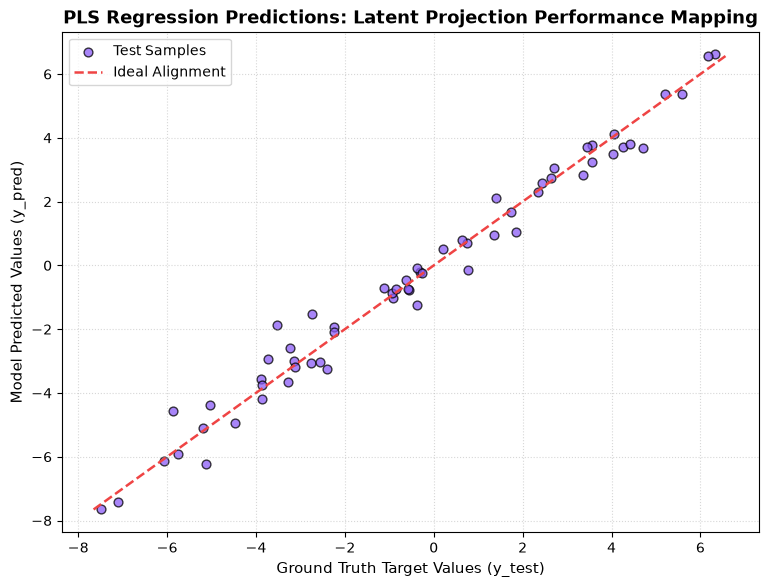

In [3]:
plt.figure(figsize=(9, 6.5))

# Plot scatter actual vs predicted
plt.scatter(y_test, y_pred, c='#8B5CF6', edgecolors='k', alpha=0.75, s=40, label='Test Samples')

# Draw ideal 45-degree diagonal line
ideal_min, ideal_max = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([ideal_min, ideal_max], [ideal_min, ideal_max], color='#EF4444', linestyle='--', linewidth=1.8, label='Ideal Alignment')

plt.title('PLS Regression Predictions: Latent Projection Performance Mapping', fontsize=13, fontweight='bold')
plt.xlabel('Ground Truth Target Values (y_test)', fontsize=11)
plt.ylabel('Model Predicted Values (y_pred)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
